# Tarea 4

#### Tópicos Selectos De Matemáticas Aplicadas II: Análisis de Datos con Python

Fecha de entrega: Domingo 13 de julio 

Alan Badillo Salas

In [1]:
import numpy
import pandas

import matplotlib.pyplot as pyplot
import seaborn

**1.** Descargue los datos de las **Carpetas de Investigación (acumulado 2016-2024)** en el sitio: https://datos.cdmx.gob.mx/dataset/carpetas-de-investigacion-fgj-de-la-ciudad-de-mexico. Con el parámetro chunksize lea los datos y realice lo siguiente:

* Obtenga un Dataframe con la frecuencia de los delitos en orden descendente y un gráfico que ilustre los primeros 15 delitos con más frecuencia. 

* Obtenga un Dataframe con los delitos cometidos por alcaldía y un gráfico que ilustre esto.

* Obtenga un Dataframe con los delitos cometidos por categoría y un gráfico que ilustre esto.

* ¿Cuales son las 5 colonias donde se han registrado más delitos?

* ¿En que hora se registraron más delitos?

* ¿Cuales son las 3 alcaldias que registraron menos delitos?

In [99]:
carpetas = pandas.read_csv("carpetasFGJ_acumulado_2025_01.csv", low_memory=False)

carpetas.head()

,anio_inicio,mes_inicio,fecha_inicio,hora_inicio,anio_hecho,mes_hecho,fecha_hecho,hora_hecho,delito,categoria_delito,...,fiscalia,agencia,unidad_investigacion,colonia_hecho,colonia_catalogo,alcaldia_hecho,alcaldia_catalogo,municipio_hecho,latitud,longitud
0,2016,Enero,2016-01-01,00:00:00,2015.0,Diciembre,2015-12-31,16:30:00,LESIONES CULPOSAS POR TRANSITO VEHICULAR EN CO...,DELITO DE BAJO IMPACTO,...,INVESTIGACIÓN EN TLALPAN,TLP-4,UI-2CD,JARDINES EN LA MONTAÑA,Jardines En La Montaña,TLALPAN,NaN,CDMX,19.30086,-99.20877
1,2016,Enero,2016-01-01,00:00:00,2015.0,Diciembre,2015-12-31,22:40:00,ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA,ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA,...,INVESTIGACIÓN EN TLALPAN,TLP-1,UI-2CD,LOMAS DE PADIERNA,Lomas De Padierna,TLALPAN,NaN,CDMX,19.29003,-99.21748
2,2016,Enero,2016-01-01,00:00:00,2016.0,Enero,2016-01-01,00:20:00,ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA,ROBO A TRANSEUNTE EN VÍA PÚBLICA CON Y SIN VIO...,...,INVESTIGACIÓN EN IZTAPALAPA,IZP-2,UI-2CD,SAN ANTONIO CULHUACÁN,Barrio San Antonio Culhuacan,IZTAPALAPA,NaN,CDMX,19.34080,-99.11431
3,2016,Enero,2016-01-01,00:00:00,2015.0,Diciembre,2015-12-31,22:00:00,ROBO DE VEHICULO DE SERVICIO PARTICULAR SIN VI...,ROBO DE VEHÍCULO CON Y SIN VIOLENCIA,...,INVESTIGACIÓN EN GUSTAVO A. MADERO,GAM-8,UI-2CD,SAN JUAN DE ARAGÓN II SECCIÓN,San Juan De Aragon Ii Seccion,GUSTAVO A. MADERO,NaN,CDMX,19.45106,-99.08669
4,2016,Enero,2016-01-01,00:00:00,2015.0,Diciembre,2015-12-31,22:30:00,HOMICIDIOS INTENCIONALES (OTROS),HOMICIDIO DOLOSO,...,INVESTIGACIÓN EN BENITO JUÁREZ,BJ-1,UI-2SD,NATIVITAS,Nativitas,BENITO JUAREZ,NaN,CDMX,19.38095,-99.13982


In [103]:
carpetas.groupby("delito").size().sort_values(ascending=False)

delito
VIOLENCIA FAMILIAR                                  261181
FRAUDE                                              156399
AMENAZAS                                            135941
ROBO DE OBJETOS                                     112702
ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA       88535
                                                     ...  
HOMICIDIO POR INMERSION                                  1
CONTRA LA LEY FEDERAL DE POBLACION                       1
INJURIAS                                                 1
ROBO A NEGOCIO (NOMINA) Y VEHICULO CON VIOLENCIA         1
ASOCIACION DELICTUOSA                                    1
Length: 357, dtype: int64

<Axes: xlabel='delito'>

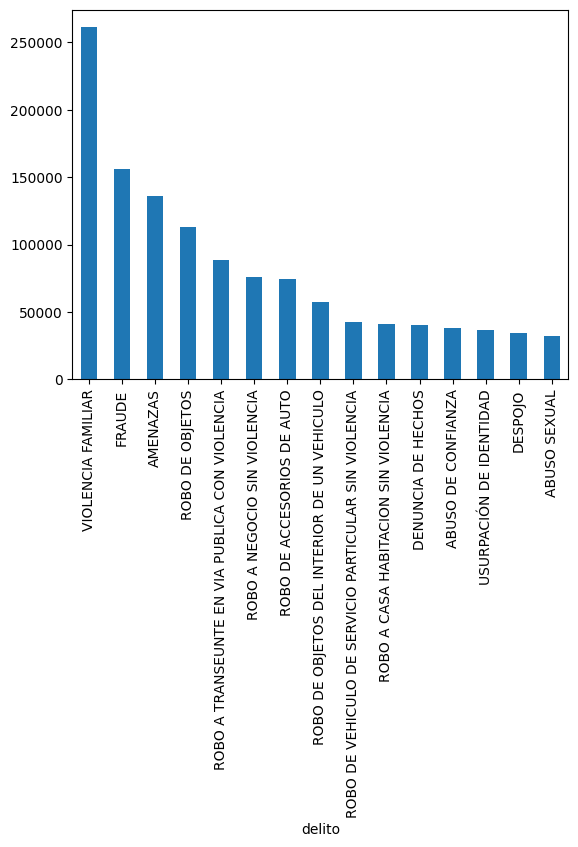

In [107]:
carpetas.groupby("delito").size().sort_values(ascending=False).iloc[:15].plot.bar()

La violencia familiar encabeza el tipo de delito, quizás es el más denunciado dentro de los otros.

In [108]:
carpetas.groupby("alcaldia_hecho").size().sort_values(ascending=False)

alcaldia_hecho
CUAUHTEMOC                318787
IZTAPALAPA                304367
GUSTAVO A. MADERO         209034
BENITO JUAREZ             164576
COYOACAN                  142074
ALVARO OBREGON            140019
MIGUEL HIDALGO            130574
TLALPAN                   125799
VENUSTIANO CARRANZA       118736
AZCAPOTZALCO               98994
IZTACALCO                  89879
XOCHIMILCO                 67289
TLAHUAC                    57691
LA MAGDALENA CONTRERAS     37189
CUAJIMALPA DE MORELOS      33282
MILPA ALTA                 17971
CDMX (indeterminada)       17586
dtype: int64

<Axes: xlabel='alcaldia_hecho'>

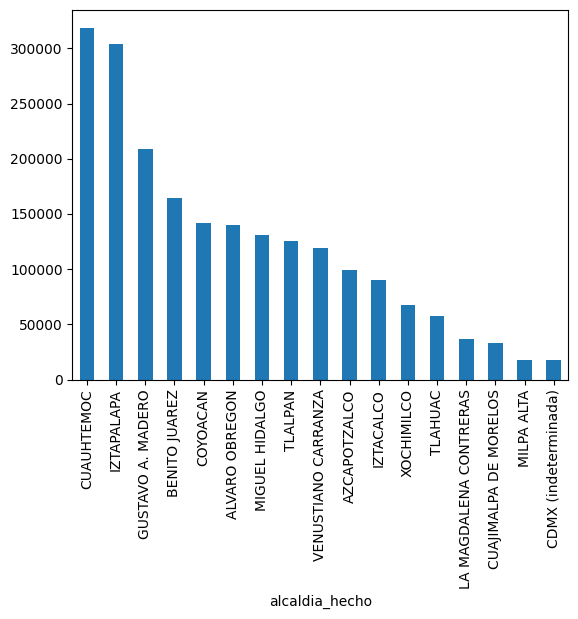

In [109]:
carpetas.groupby("alcaldia_hecho").size().sort_values(ascending=False).plot.bar()

Las alcaldía Cuahtemoc e Iztapalapa son las de mayor cantidad de delitos.

In [110]:
carpetas.groupby("categoria_delito").size().sort_values(ascending=False)

categoria_delito
DELITO DE BAJO IMPACTO                                     1711755
ROBO A TRANSEUNTE EN VÍA PÚBLICA CON Y SIN VIOLENCIA        104401
ROBO DE VEHÍCULO CON Y SIN VIOLENCIA                         90384
HECHO NO DELICTIVO                                           75553
ROBO A NEGOCIO CON VIOLENCIA                                 27993
ROBO A REPARTIDOR CON Y SIN VIOLENCIA                        16928
VIOLACIÓN                                                    16321
ROBO A PASAJERO A BORDO DEL METRO CON Y SIN VIOLENCIA        15760
LESIONES DOLOSAS POR DISPARO DE ARMA DE FUEGO                12249
HOMICIDIO DOLOSO                                             10443
ROBO A PASAJERO A BORDO DE MICROBUS CON Y SIN VIOLENCIA       6603
ROBO A CASA HABITACIÓN CON VIOLENCIA                          4190
ROBO A CUENTAHABIENTE SALIENDO DEL CAJERO CON VIOLENCIA       3119
ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA                 1987
ROBO A TRANSPORTISTA CON Y SIN VIOLENCIA     

<Axes: xlabel='categoria_delito'>

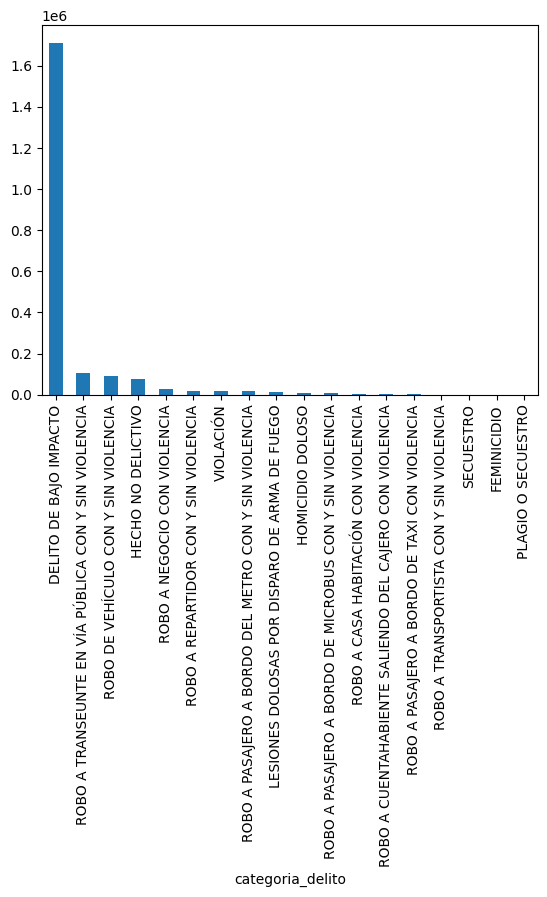

In [111]:
carpetas.groupby("categoria_delito").size().sort_values(ascending=False).plot.bar()

Los delitos de bajo impacto superan por mucho a los otros.

In [113]:
carpetas.groupby("colonia_hecho").size().sort_values(ascending=False).iloc[:5]

colonia_hecho
CENTRO              65086
DOCTORES            38978
DEL VALLE CENTRO    28178
ROMA NORTE          24209
NARVARTE            20080
dtype: int64

Las colonias con mayor cantidad de delitos son el Centro, Doctores, Del Valle, Roma Norte y Narvarte.

In [132]:
carpetas["hora"] = carpetas["hora_hecho"].str.extract(r"^(\d{2}):")

carpetas.groupby("hora").size().sort_values(ascending=False)

hora
12    266208
10    144778
11    113992
14    109197
15    108461
13    102083
20    101678
16    100658
09    100148
18     97314
19     95971
17     95696
21     87354
08     80926
22     73226
07     66525
23     58603
00     53819
06     50264
01     43368
02     39693
05     38042
03     37580
04     32260
dtype: int64

<Axes: xlabel='hora'>

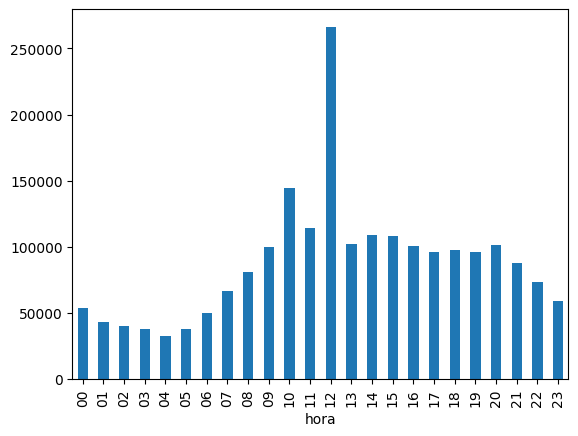

In [133]:
carpetas.groupby("hora").size().plot.bar()

A las 12 horas se registran más delitos, esto se puede deber a que hay más gente en la calle o se activan más los delincuentes, deberíamos excluir el delito de bajo impacto.

In [144]:
carpetas["delito"].value_counts().sort_values(ascending=False).index

Index(['VIOLENCIA FAMILIAR', 'FRAUDE', 'AMENAZAS', 'ROBO DE OBJETOS',
       'ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA',
       'ROBO A NEGOCIO SIN VIOLENCIA', 'ROBO DE ACCESORIOS DE AUTO',
       'ROBO DE OBJETOS DEL INTERIOR DE UN VEHICULO',
       'ROBO DE VEHICULO DE SERVICIO PARTICULAR SIN VIOLENCIA',
       'ROBO A CASA HABITACION SIN VIOLENCIA',
       ...
       'ROBO DE VEHICULO Y NOMINA CON VIOLENCIA', 'INJURIAS',
       'HOMICIDIO INTENCIONAL Y ROBO DE VEHICULO', 'ASOCIACION DELICTUOSA',
       'CONTRA LA LEY GENERAL DE EXPLOSIVOS',
       'ROBO A NEGOCIO (NOMINA) Y VEHICULO CON VIOLENCIA',
       'CONTRA LA LEY FEDERAL DE POBLACION', 'HOMICIDIO POR INMERSION',
       'SECUESTRO', 'VIOLACION A LOS DERECHOS HUMANOS'],
      dtype='object', name='delito', length=357)

<Axes: xlabel='hora'>

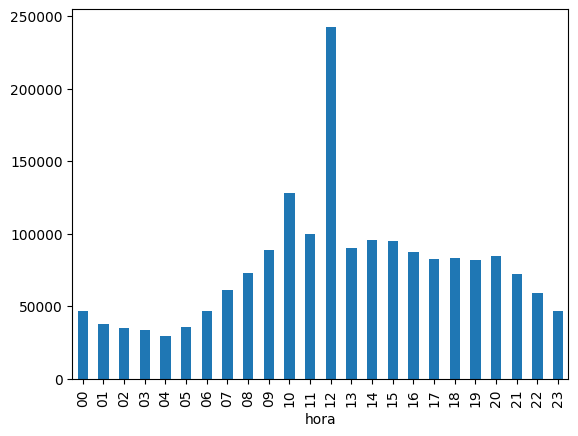

In [145]:
carpetas[carpetas["delito"] != "VIOLENCIA FAMILIAR"].groupby("hora").size().plot.bar()

Aún quitando los delitos por violencia familiar, la tendencia es sililar, aunque se ve un ligero aumento a las 20 horas.

In [116]:
carpetas.groupby("alcaldia_hecho").size().sort_values(ascending=True).iloc[:4]

alcaldia_hecho
CDMX (indeterminada)      17586
MILPA ALTA                17971
CUAJIMALPA DE MORELOS     33282
LA MAGDALENA CONTRERAS    37189
dtype: int64

Las alcaldías con menor cantidad de delitos son Milpa Alta, Cuajimalpa y Magdalena Contreras.

**2.** Extraiga las tablas que aparecen en la página web:

https://es.wikipedia.org/wiki/Primera_Divisi%C3%B3n_de_M%C3%A9xico

y realice lo siguiente:

* Obtenga un gráfico de la capacidad de los estadios de la liga mx en orden descendente.

* Obtenga un gráfico de los 10 equipos con más títulos en orden ascendente.

* Obtenga un gráfico de directores técnicos con más títulos en orden ascendente.

* De la tabla de directores técnicos con más títulos conteste lo siguiente: ¿Cuantos de estos directores técnicos conquistaron un título con Guadalajara? ¿Cuantos de estos directores técnicos conquistaron un título con América? (Utilice variables dummy).

In [5]:
tablas = pandas.read_html("https://es.wikipedia.org/wiki/Primera_Divisi%C3%B3n_de_M%C3%A9xico")

In [27]:
estadios = tablas[2].iloc[2:].copy()

estadios.columns = tablas[2].iloc[1]

estadios["Capacidad"] = estadios["Capacidad"].str.replace(r"\D", "", regex=True).astype("Int64")

estadios.sort_values("Capacidad", ascending=False)

1,Equipo,Debut,Presencias,En 1.ª desde,Serie,Estadio,Capacidad
19,Universidad Nacional,1962-63,93,1962-63,93,Olímpico Universitario,73000
5,C. D. Cruz Azul,1964-65,91,1964-65,91,Olímpico Universitario,73000
3,Atlas F. C.,1943-44,109,1979-80,75,Jalisco,55020
10,C. F. Monterrey,1945-46,97,1960-61,95,BBVA,53500
13,Club Puebla,1944-45,92,2007-08,35,Cuauhtémoc,51726
6,C. D. Guadalajara,1943-44,112,1943-44,112,Akron,49850
16,Tigres de la UANL,1974-75,78,1997-98,55,Universitario,41615
2,Club América,1943-44,112,1943-44,112,Ciudad de los Deportes,36681
14,Querétaro F. C.,1990-91,41,2009-10,31,Corregidora,35575
12,C. F. Pachuca,1967-68,63,1998-99,53,Hidalgo,32000


In [28]:
estadios[["Estadio", "Capacidad"]].groupby("Estadio").max().sort_values("Capacidad", ascending=False)

1,Capacidad
Estadio,
Olímpico Universitario,73000
Jalisco,55020
BBVA,53500
Cuauhtémoc,51726
Akron,49850
Universitario,41615
Ciudad de los Deportes,36681
Corregidora,35575
Hidalgo,32000


<Axes: ylabel='Estadio'>

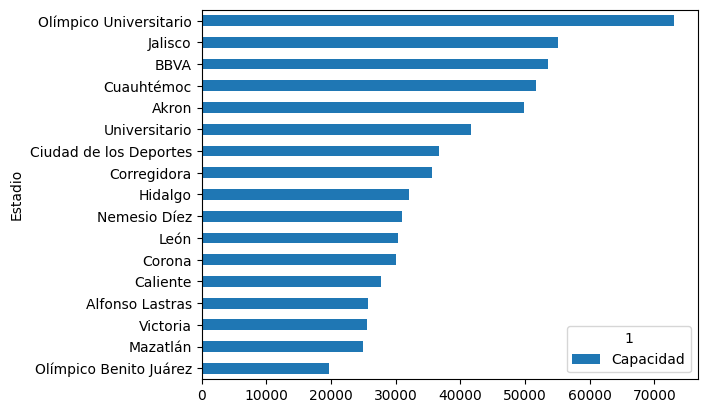

In [32]:
estadios[["Estadio", "Capacidad"]].groupby("Estadio").max().sort_values("Capacidad").plot.barh()

In [36]:
tablas[4]

,Club,Títulos,Subtítulos,Años de los campeonatos,Años subcampeón
0,C. F. América,16,11,"1965-66, 1970-71, 1975-76, 1983-84, 1984-85, P...","1959-60, 1961-62, 1963-64, 1966-67, 1971-72, 1..."
1,C. D. Guadalajara,12,10,"1956-57, 1958-59, 1959-60, 1960-61, 1961-62, 1...","1951-52, 1954-55, 1962-63, 1968-69, M-1970, 19..."
2,Deportivo Toluca F. C.,11,8,"1966-67, 1967-68, 1974-75, V-1998, V-1999, V-2...","1956-57, 1957-58, 1970-71, I-2000, A-2006, A-2..."
3,C. D. Cruz Azul,9,12,"1968-69, M-1970, 1971-72, 1972-73, 1973-74, 19...","1969-70, 1980-81, 1986-87, 1988-89, 1994-95, I..."
4,Club León,8,7,"1947-48, 1948-49, 1951-52, 1955-56, 1991-92, A...","1946-47, 1958-59, 1972-73, 1974-75, I-1997, C-..."
5,C. F. Tigres UANL,8,6,"1977-78, 1981-82, A-2011, A-2015, A-2016, A-20...","1979-80, I-2001, A-2003, A-2014, C-2017 y A-2023"
6,Universidad Nacional,7,8,"1976-77, 1980-81, 1990-91, C-2004, A-2004, C-2...","1967-68, 1977-78, 1978-79, 1984-85, 1987-88, A..."
7,C. F. Pachuca,7,4,"I-1999, I-2001, A-2003, C-2006, C-2007, C-2016...","V-2001, C-2009, C-2014 y C-2022"
8,Santos Laguna,6,6,"I-1996, V-2001, C-2008, C-2012, C-2015 y C-2018","1993-94, V-2000, B-2010, A-2010, A-2011 y G-2021"
9,C. F. Monterrey,5,7,"M-1986, C-2003, A-2009, A-2010 y A-2019","1992-93, A-2004, A-2005, C-2012, C-2016, A-201..."


In [48]:
equipos = tablas[4].copy()

equipos["Títulos"] = equipos["Títulos"].str.replace("-", "0").astype("Int64")

equipos = equipos.sort_values("Títulos", ascending=False).iloc[:10].set_index("Club")

equipos

,Títulos,Subtítulos,Años de los campeonatos,Años subcampeón
Club,,,,
C. F. América,16,11,"1965-66, 1970-71, 1975-76, 1983-84, 1984-85, P...","1959-60, 1961-62, 1963-64, 1966-67, 1971-72, 1..."
C. D. Guadalajara,12,10,"1956-57, 1958-59, 1959-60, 1960-61, 1961-62, 1...","1951-52, 1954-55, 1962-63, 1968-69, M-1970, 19..."
Deportivo Toluca F. C.,11,8,"1966-67, 1967-68, 1974-75, V-1998, V-1999, V-2...","1956-57, 1957-58, 1970-71, I-2000, A-2006, A-2..."
C. D. Cruz Azul,9,12,"1968-69, M-1970, 1971-72, 1972-73, 1973-74, 19...","1969-70, 1980-81, 1986-87, 1988-89, 1994-95, I..."
Club León,8,7,"1947-48, 1948-49, 1951-52, 1955-56, 1991-92, A...","1946-47, 1958-59, 1972-73, 1974-75, I-1997, C-..."
C. F. Tigres UANL,8,6,"1977-78, 1981-82, A-2011, A-2015, A-2016, A-20...","1979-80, I-2001, A-2003, A-2014, C-2017 y A-2023"
Universidad Nacional,7,8,"1976-77, 1980-81, 1990-91, C-2004, A-2004, C-2...","1967-68, 1977-78, 1978-79, 1984-85, 1987-88, A..."
C. F. Pachuca,7,4,"I-1999, I-2001, A-2003, C-2006, C-2007, C-2016...","V-2001, C-2009, C-2014 y C-2022"
Santos Laguna,6,6,"I-1996, V-2001, C-2008, C-2012, C-2015 y C-2018","1993-94, V-2000, B-2010, A-2010, A-2011 y G-2021"


<Axes: ylabel='Club'>

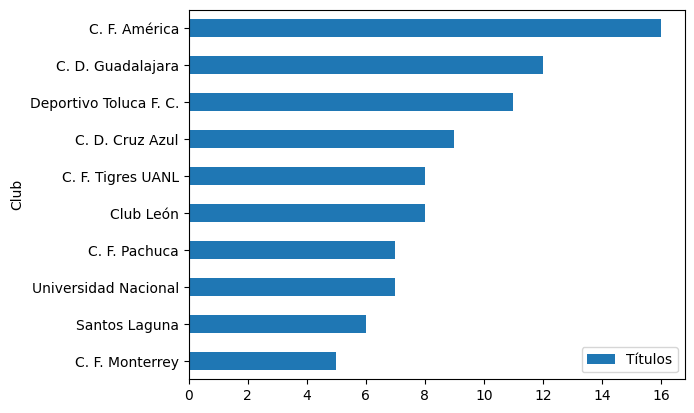

In [49]:
equipos.sort_values("Títulos").plot.barh()

In [67]:
tablas[11]

,N.º,Entrenador,Títulos,Periodo,Equipos,Campeonatos
0,1,Ignacio Trelles,7,1951 - 1991,"Marte (1), Zacatepec (2), Deportivo Toluca (2)...","1953-54, 1954-55, 1957-58, 1966-67, 1967-68, 1..."
1,1,Ricardo Ferretti,7,1991 -,"Guadalajara (1), UNAM (1), Tigres UANL (5)","V1997, C2009, A2011, A2015, A2016, A2017, C2019"
2,3,Raúl Cárdenas,6,1966 - 1998,"Cruz Azul (5), América (1)","1968-69, México 1970, 1971-72, 1972-73, 1973-7..."
3,4,Javier de la Torre,5,1955 - 1984,Guadalajara (5),"1960-61, 1961-62, 1963-64, 1964-65, 1969-70"
4,4,Manuel Lapuente,5,1978 - 2013,"Puebla (2), Necaxa (2), América (1)","1982-83, 1989-90, 1994-95, 1995-96, V2002"
5,4,Víctor Manuel Vucetich,5,1990 -,"León (1), Tecos (1), Pachuca (1), Monterrey (2)","1991-92, 1993-94, A2003, A2009, A2010"
6,7,Enrique Meza,4,1982 -,"Toluca (3), Pachuca (1)","V1998, V1999, V2000, C2007"
7,7,Antonio Mohamed,4,2004 -,"Tijuana (1), América (1), Monterrey (1), Toluc...","A2012, A2014, A2019, C2025"
8,8,Árpád Fekete,3,1957 - 1990,"Guadalajara (2), Club Oro (1)","1958-59, 1959-60, 1962-63"
9,8,José Manuel de la Torre,3,2006 -,"Guadalajara (1), Toluca (2)","A2006, A2008, Bicentenario 2010"


In [71]:
directores = tablas[11].copy()

directores = directores.set_index("Entrenador")

directores.sort_values("Títulos", ascending=False)

,N.º,Títulos,Periodo,Equipos,Campeonatos
Entrenador,,,,,
Ignacio Trelles,1,7,1951 - 1991,"Marte (1), Zacatepec (2), Deportivo Toluca (2)...","1953-54, 1954-55, 1957-58, 1966-67, 1967-68, 1..."
Ricardo Ferretti,1,7,1991 -,"Guadalajara (1), UNAM (1), Tigres UANL (5)","V1997, C2009, A2011, A2015, A2016, A2017, C2019"
Raúl Cárdenas,3,6,1966 - 1998,"Cruz Azul (5), América (1)","1968-69, México 1970, 1971-72, 1972-73, 1973-7..."
Javier de la Torre,4,5,1955 - 1984,Guadalajara (5),"1960-61, 1961-62, 1963-64, 1964-65, 1969-70"
Manuel Lapuente,4,5,1978 - 2013,"Puebla (2), Necaxa (2), América (1)","1982-83, 1989-90, 1994-95, 1995-96, V2002"
Víctor Manuel Vucetich,4,5,1990 -,"León (1), Tecos (1), Pachuca (1), Monterrey (2)","1991-92, 1993-94, A2003, A2009, A2010"
Enrique Meza,7,4,1982 -,"Toluca (3), Pachuca (1)","V1998, V1999, V2000, C2007"
Antonio Mohamed,7,4,2004 -,"Tijuana (1), América (1), Monterrey (1), Toluc...","A2012, A2014, A2019, C2025"
Árpád Fekete,8,3,1957 - 1990,"Guadalajara (2), Club Oro (1)","1958-59, 1959-60, 1962-63"


<Axes: ylabel='Entrenador'>

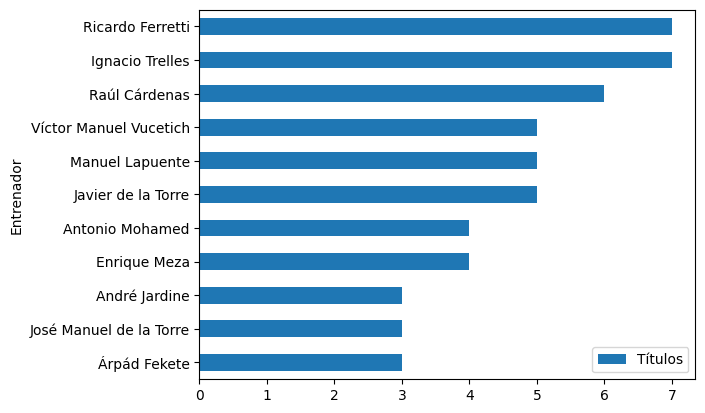

In [74]:
directores[["Títulos"]].sort_values("Títulos").plot.barh()

In [88]:
clubes = []

for row in directores["Equipos"].str.replace(r"\s*\(\d+\)\s*", "", regex=True).str.split(r",\s+"):
    clubes.extend(row)

clubes = set(clubes)

clubes

{'América',
 'Club Oro',
 'Cruz Azul',
 'Deportivo Toluca',
 'Guadalajara',
 'León',
 'Marte',
 'Monterrey',
 'Necaxa',
 'Pachuca',
 'Puebla',
 'Tecos',
 'Tigres UANL',
 'Tijuana',
 'Toluca',
 'UNAM',
 'Zacatepec'}

In [95]:
for club in clubes:
    # print(club, directores["Equipos"].str.match(club))
    directores[f"Club_{club}"] = directores["Equipos"].str.match(club).astype("Int64")

directores

,N.º,Títulos,Periodo,Equipos,Campeonatos,Club_Guadalajara,Club_Zacatepec,Club_Tecos,Club_América,Club_Tigres UANL,...,Club_UNAM,Club_Pachuca,Club_Monterrey,Club_Cruz Azul,Club_Marte,Club_Deportivo Toluca,Club_Toluca,Club_Necaxa,Club_Tijuana,Club_Puebla
Entrenador,,,,,,,,,,,,,,,,,,,,,
Ignacio Trelles,1,7,1951 - 1991,"Marte (1), Zacatepec (2), Deportivo Toluca (2)...","1953-54, 1954-55, 1957-58, 1966-67, 1967-68, 1...",0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
Ricardo Ferretti,1,7,1991 -,"Guadalajara (1), UNAM (1), Tigres UANL (5)","V1997, C2009, A2011, A2015, A2016, A2017, C2019",1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Raúl Cárdenas,3,6,1966 - 1998,"Cruz Azul (5), América (1)","1968-69, México 1970, 1971-72, 1972-73, 1973-7...",0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
Javier de la Torre,4,5,1955 - 1984,Guadalajara (5),"1960-61, 1961-62, 1963-64, 1964-65, 1969-70",1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Manuel Lapuente,4,5,1978 - 2013,"Puebla (2), Necaxa (2), América (1)","1982-83, 1989-90, 1994-95, 1995-96, V2002",0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
Víctor Manuel Vucetich,4,5,1990 -,"León (1), Tecos (1), Pachuca (1), Monterrey (2)","1991-92, 1993-94, A2003, A2009, A2010",0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Enrique Meza,7,4,1982 -,"Toluca (3), Pachuca (1)","V1998, V1999, V2000, C2007",0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
Antonio Mohamed,7,4,2004 -,"Tijuana (1), América (1), Monterrey (1), Toluc...","A2012, A2014, A2019, C2025",0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
Árpád Fekete,8,3,1957 - 1990,"Guadalajara (2), Club Oro (1)","1958-59, 1959-60, 1962-63",1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [96]:
directores[["Club_Guadalajara", "Club_América"]]

,Club_Guadalajara,Club_América
Entrenador,,
Ignacio Trelles,0,0
Ricardo Ferretti,1,0
Raúl Cárdenas,0,0
Javier de la Torre,1,0
Manuel Lapuente,0,0
Víctor Manuel Vucetich,0,0
Enrique Meza,0,0
Antonio Mohamed,0,0
Árpád Fekete,1,0


In [97]:
directores[["Club_Guadalajara", "Club_América"]].sum()

Club_Guadalajara    4
Club_América        1
dtype: Int64

Cuatro directores conquistaron al menos un título con el Guadalajara y solo uno con el América (André Jardine).

**3.** Cargue los datos de los ingresos de la Ciudad de México en el año 2021 (**ingresos_CDMX_2021.csv** en GitHub) y realice lo siguiente:

* Elimine la cadena "desc_" en cada columna que la contenga.

* Limpie las cadenas de caracteres contenidas en las columnas
(esto es, elimine caracteres como Û, ¢, °, Ì, etc.)

* La única variable numérica debe ser la variable "monto_recaudado".

* Obtenga un Dataframe que describa el monto recaudado en cada rubro. Obtenga una gráfica que ilustre esto.

* Obtenga un Dataframe que describa el monto recaudado en cada rubro y el tipo de rubro.

* Obtenga un Dataframe que describa el monto recaudado en cada trimestre.  Obtenga una gráfica que ilustre esto.

* Obtenga un Dataframe que describa el monto recaudado en cada rubro en los tres trimestres.  Obtenga una gráfica que ilustre esto.

* Coloque en orden alfabético el Dataframe anterior de acuerdo al rubro (1er índice).

* ¿Cuál fue el monto total recaudado por la CDMX en 2021?

* ¿De cuánto fue el endeudamiento interno?

In [154]:
ingresos = pandas.read_csv("ingresos_CDMX_2021.csv")

ingresos.head()

,ciclo,periodo,desc_tipo_recurso_clase,desc_rubro,desc_tipo,desc_clase,desc_concepto,desc_concepto_esp,monto_recaudado
0,2021,Primer Trimestre,Ingresos locales,Impuestos,Impuestos sobre el patrimonio,Predial,NaN,NaN,1.247781e+10
1,2021,Primer Trimestre,Ingresos locales,Impuestos,Impuestos sobre el patrimonio,Sobre Adquisici¢n de Inmuebles,NaN,NaN,1.794347e+09
2,2021,Primer Trimestre,Ingresos locales,Impuestos,Impuestos sobre el patrimonio,Sobre Tenencia o Uso de Veh°culos,NaN,NaN,3.427249e+09
3,2021,Primer Trimestre,Ingresos locales,Impuestos,"Impuestos sobre la producci¢n, el consumo y la...",Sobre Espect†culos P£blicos,NaN,NaN,6.500144e+07
4,2021,Primer Trimestre,Ingresos locales,Impuestos,"Impuestos sobre la producci¢n, el consumo y la...","Sobre Loter°as, Rifas, Sorteos y Concursos",NaN,NaN,6.819808e+07


In [155]:
ingresos.columns = ingresos.columns.str.removeprefix("desc_")

ingresos.head()

,ciclo,periodo,tipo_recurso_clase,rubro,tipo,clase,concepto,concepto_esp,monto_recaudado
0,2021,Primer Trimestre,Ingresos locales,Impuestos,Impuestos sobre el patrimonio,Predial,NaN,NaN,1.247781e+10
1,2021,Primer Trimestre,Ingresos locales,Impuestos,Impuestos sobre el patrimonio,Sobre Adquisici¢n de Inmuebles,NaN,NaN,1.794347e+09
2,2021,Primer Trimestre,Ingresos locales,Impuestos,Impuestos sobre el patrimonio,Sobre Tenencia o Uso de Veh°culos,NaN,NaN,3.427249e+09
3,2021,Primer Trimestre,Ingresos locales,Impuestos,"Impuestos sobre la producci¢n, el consumo y la...",Sobre Espect†culos P£blicos,NaN,NaN,6.500144e+07
4,2021,Primer Trimestre,Ingresos locales,Impuestos,"Impuestos sobre la producci¢n, el consumo y la...","Sobre Loter°as, Rifas, Sorteos y Concursos",NaN,NaN,6.819808e+07


In [157]:
for column in ingresos.columns:
    if ingresos[column].dtype == object:
        ingresos[column] = ingresos[column].str.replace(r"[^\w\s]", "", regex=True)

ingresos.head()

,ciclo,periodo,tipo_recurso_clase,rubro,tipo,clase,concepto,concepto_esp,monto_recaudado
0,2021,Primer Trimestre,Ingresos locales,Impuestos,Impuestos sobre el patrimonio,Predial,NaN,NaN,1.247781e+10
1,2021,Primer Trimestre,Ingresos locales,Impuestos,Impuestos sobre el patrimonio,Sobre Adquisicin de Inmuebles,NaN,NaN,1.794347e+09
2,2021,Primer Trimestre,Ingresos locales,Impuestos,Impuestos sobre el patrimonio,Sobre Tenencia o Uso de Vehculos,NaN,NaN,3.427249e+09
3,2021,Primer Trimestre,Ingresos locales,Impuestos,Impuestos sobre la produccin el consumo y las ...,Sobre Espectculos Pblicos,NaN,NaN,6.500144e+07
4,2021,Primer Trimestre,Ingresos locales,Impuestos,Impuestos sobre la produccin el consumo y las ...,Sobre Loteras Rifas Sorteos y Concursos,NaN,NaN,6.819808e+07


In [160]:
ingresos["monto_recaudado"] = ingresos["monto_recaudado"].map(int)

ingresos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ciclo               240 non-null    int64 
 1   periodo             240 non-null    object
 2   tipo_recurso_clase  240 non-null    object
 3   rubro               240 non-null    object
 4   tipo                240 non-null    object
 5   clase               225 non-null    object
 6   concepto            81 non-null     object
 7   concepto_esp        18 non-null     object
 8   monto_recaudado     240 non-null    int64 
dtypes: int64(2), object(7)
memory usage: 17.0+ KB


In [161]:
ingresos.groupby("rubro")[["monto_recaudado"]].sum()

,monto_recaudado
rubro,
Aprovechamientos,11377912552
Cuotas y Aportaciones de Seguridad Social,6485682674
Derechos,20641043124
Impuestos,111041802626
Ingresos Derivados de Financiamientos,-4913614000
Ingresos por Venta de Bienes Prestacin de Servicios y Otros Ingresos,9382517404
Ingresos por Venta de Bienes PrestaciÛn de Servicios y Otros Ingresos,10726148154
Participaciones Aportaciones Convenios Incentivos Derivados de la Colaboracin Fiscal y Fondos Distintos de Aportaciones,95152184879
Participaciones Aportaciones Convenios Incentivos Derivados de la ColaboraciÛn Fiscal y Fondos Distintos de Aportaciones,90835778612


<Axes: xlabel='rubro'>

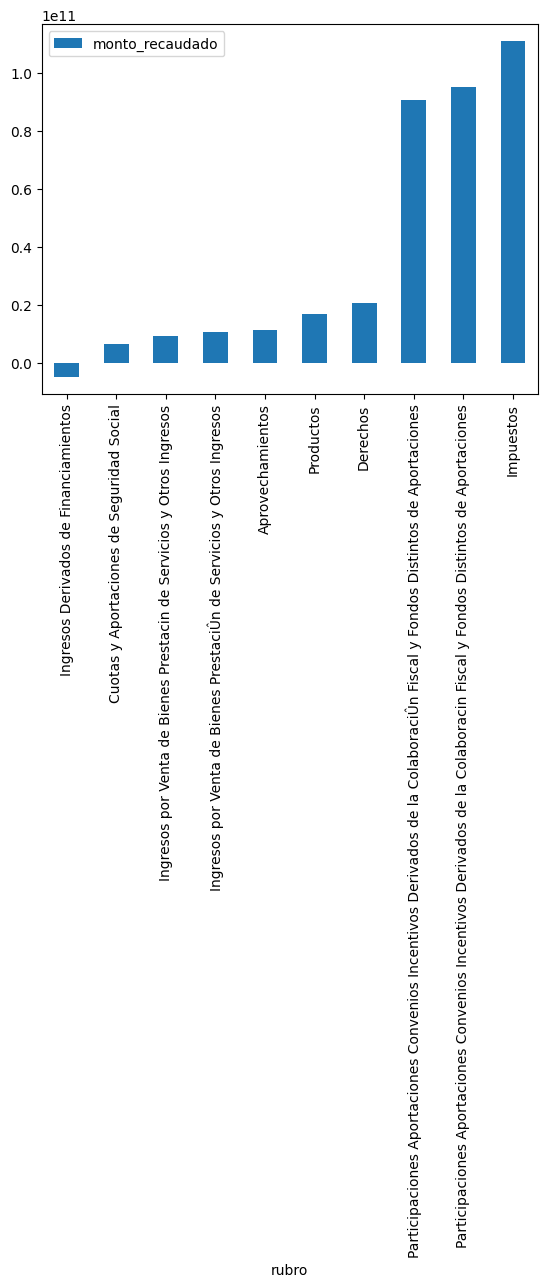

In [163]:
ingresos.groupby("rubro")[["monto_recaudado"]].sum().sort_values("monto_recaudado").plot.bar()

In [165]:
ingresos.groupby(["rubro", "tipo"])[["monto_recaudado"]].sum()

monto_recaudado
rubro                                              tipo                                                               
Aprovechamientos                                   Aprovechamientos                                        11377912552
Cuotas y Aportaciones de Seguridad Social          Otras Cuotas y Aportaciones para la Seguridad S...       6485682674
Derechos                                           Accesorios de los Derechos                                297118474
                                                   Derechos por el uso goce aprovechamiento o expl...        372299966
                                                   Derechos por el uso goce aprovechamiento o expl...        387890002
                                                   Derechos por prestacin de servicios                     10076349832
                                                   Derechos por prestaciÛn de servicios                     9078978175
                                                   Otros Derechos                                            428406675
Impuestos                                          Accesorios de los Impuestos                               767094101
                                                   Impuestos sobre Nminas y Asimilables                    22037550341
                                                   Impuestos sobre NÛminas y Asimilables                   20971958618
                                                   Impuestos sobre el patrimonio                           65896430733
                                                   Impuestos sobre la produccin el consumo y las t...        644233295
                                                   Impuestos sobre la producciÛn el consumo y las ...        724535538
Ingresos Derivados de Financiamientos              Endeudamiento interno                                   -4913614000
Ingresos por Venta de Bienes Prestacin de Servi... Ingresos por Venta de Bienes y Prestacin de Ser...        403835481
                                                   Ingresos por Venta de Bienes y Prestacin de Ser...       7171272316
                                                   Ingresos por Venta de Bienes y Prestacin de Ser...       1807409607
Ingresos por Venta de Bienes PrestaciÛn de Serv... Ingresos por Venta de Bienes y PrestaciÛn de Se...        343033887
                                                   Ingresos por Venta de Bienes y PrestaciÛn de Se...       8036005631
                                                   Ingresos por Venta de Bienes y PrestaciÛn de Se...       2347108636
Participaciones Aportaciones Convenios Incentiv... Aportaciones                                            13057219262
                                                   Convenios                                                5861670258
                                                   Fondos Distintos de Aportaciones                         2361035053
                                                   Incentivos derivados de la colaboracin fiscal            2894434662
                                                   Participaciones                                         70977825644
Participaciones Aportaciones Convenios Incentiv... Aportaciones                                            12794475482
                                                   Convenios                                                5742793721
                                                   Fondos Distintos de Aportaciones                          516199392
                                                   Incentivos derivados de la colaboraciÛn fiscal           2946078424
                                                   Participaciones                                         68836231593
Productos                                          Productos                                               16714862801

In [166]:
ingresos.groupby("periodo")[["monto_recaudado"]].sum()

,monto_recaudado
periodo,
Primer Trimestre,65906493384
Segundo Trimestre,123884248659
Tercer Trimestre,177653576783


In [168]:
ingresos.groupby(["rubro", "periodo"])[["monto_recaudado"]].sum()

monto_recaudado
rubro                                              periodo                           
Aprovechamientos                                   Primer Trimestre        1105177937
                                                   Segundo Trimestre       4123707282
                                                   Tercer Trimestre        6149027333
Cuotas y Aportaciones de Seguridad Social          Primer Trimestre        1018018654
                                                   Segundo Trimestre       2103876070
                                                   Tercer Trimestre        3363787950
Derechos                                           Primer Trimestre        4174313104
                                                   Segundo Trimestre       6640586436
                                                   Tercer Trimestre        9826143584
Impuestos                                          Primer Trimestre       25658067679
                                                   Segundo Trimestre      37313507561
                                                   Tercer Trimestre       48070227386
Ingresos Derivados de Financiamientos              Primer Trimestre       -1563218883
                                                   Segundo Trimestre      -3134022627
                                                   Tercer Trimestre        -216372490
Ingresos por Venta de Bienes Prestacin de Servi... Primer Trimestre        2313235612
                                                   Segundo Trimestre       7069281792
Ingresos por Venta de Bienes PrestaciÛn de Serv... Tercer Trimestre       10726148154
Participaciones Aportaciones Convenios Incentiv... Primer Trimestre       30847515928
                                                   Segundo Trimestre      64304668951
Participaciones Aportaciones Convenios Incentiv... Tercer Trimestre       90835778612
Productos                                          Primer Trimestre        2353383353
                                                   Segundo Trimestre       5462643194
                                                   Tercer Trimestre        8898836254

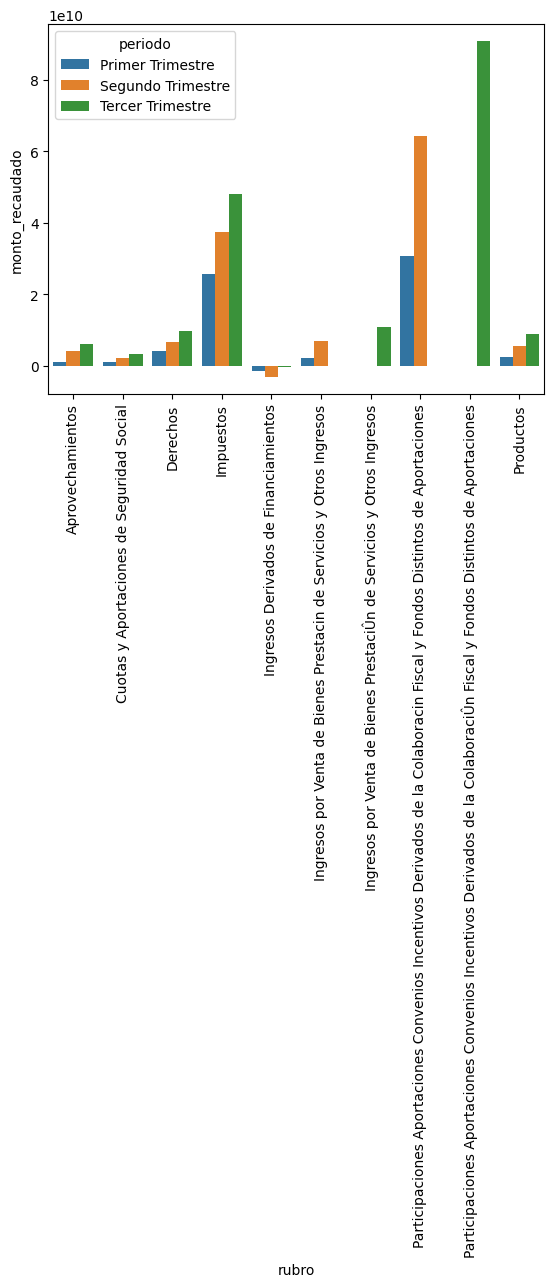

In [173]:
reporte = ingresos.groupby(["rubro", "periodo"])[["monto_recaudado"]].sum()

seaborn.barplot(reporte, x="rubro", y="monto_recaudado", hue="periodo")
pyplot.xticks(rotation=90)
pyplot.show()

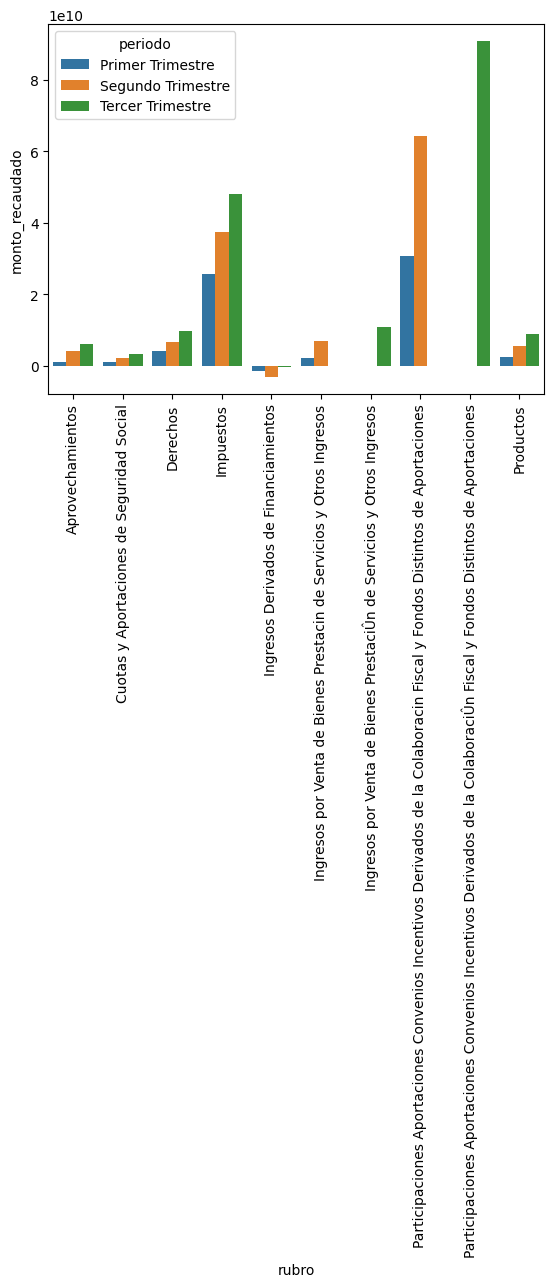

In [174]:
reporte = ingresos.groupby(["rubro", "periodo"])[["monto_recaudado"]].sum().sort_values("rubro")

seaborn.barplot(reporte, x="rubro", y="monto_recaudado", hue="periodo")
pyplot.xticks(rotation=90)
pyplot.show()

In [177]:
ingresos["ciclo"].unique()

array([2021])

In [175]:
ingresos.groupby("periodo")[["monto_recaudado"]].sum()

,monto_recaudado
periodo,
Primer Trimestre,65906493384
Segundo Trimestre,123884248659
Tercer Trimestre,177653576783


In [176]:
ingresos.groupby("periodo")[["monto_recaudado"]].sum().sum()

monto_recaudado    367444318826
dtype: int64

El monto recaudado para 2021 fue de 367,444,318,836 (poco más de 367 mil millones)

**4.** Una empresa realiza entrevistas a 20 candidatos para un puesto.
De esos 20 candidatos, 14 son mujeres y 6 son hombres.

Al final del proceso, se seleccionan 8 personas, de las cuales 7 son mujeres.

Un analista externo se pregunta si el proceso de selección favoreció a las mujeres.
Instrucciones:

- Plantea una prueba de hipótesis para evaluar si hubo favoritismo hacia las mujeres.
    - Define la hipótesis nula: la selección fue aleatoria (sin favoritismo).
    - Define la hipótesis alternativa: hay favoritismo hacia las mujeres.

- Simula mediante Monte Carlo el proceso de seleccionar 8 personas al azar de los 20 candidatos, repitiendo esto al menos 100,000 veces.

- Calcula el p-valor como la proporción de simulaciones en las que 7 o más mujeres fueron seleccionadas.

- Concluye si hay evidencia suficiente para pensar que el proceso favoreció a las mujeres. Usa un nivel de significancia de 5 %.

* $H_0$ - La selección fue aleatoria
  * de 20 candidatos se seleccionan 8 personas (sin favoritismo)
* $H_1$ - Hubo favoritismo en la elección

In [180]:
candidatos = ["M"] * 14 + ["H"] * 6

pandas.Series(candidatos)

0     M
1     M
2     M
3     M
4     M
5     M
6     M
7     M
8     M
9     M
10    M
11    M
12    M
13    M
14    H
15    H
16    H
17    H
18    H
19    H
dtype: object

In [183]:
observado = ["M"] * 7 + ["H"]

observado

['M', 'M', 'M', 'M', 'M', 'M', 'M', 'H']

Calculamos una permutación de los candidatos (proceso aleatorio)

In [186]:
numpy.random.permutation(candidatos)

array(['M', 'M', 'M', 'M', 'H', 'M', 'M', 'H', 'M', 'M', 'H', 'M', 'H',
       'H', 'M', 'M', 'M', 'H', 'M', 'M'], dtype='<U1')

Realizamos la selección de 8 (arbitrariamente los primeros 8)

In [187]:
numpy.random.permutation(candidatos)[:8]

array(['M', 'M', 'M', 'H', 'M', 'M', 'M', 'H'], dtype='<U1')

In [188]:
epocas = 100_000

cadenas = []

for epoca in range(epocas):
    seleccionados = numpy.random.permutation(candidatos)[:8]
    cadenas.append(seleccionados)

len(cadenas)

100000

In [190]:
total_mujeres = numpy.array([pandas.Series(seleccionados).map({ "H": 0, "M": 1 }).sum() for seleccionados in cadenas])

total_mujeres

array([6, 6, 5, ..., 4, 4, 6])

In [195]:
p_valor = (total_mujeres >= 7).mean()

print(f"P-Valor: {p_valor * 100:.1f}%")

P-Valor: 18.6%


El **p-valor** es mayor al 5% (18.6%), lo que significa que no hay evidencia suficiente para rechazar la hipótesis nula sobre que hubo favoritismo en la elección.

Por lo que: No hay suficiente evidencia para creer que hubo favoritismo.

**5.** Cargue en un objeto 'defunciones' las columnas 'edad', 'sexo','estado' y 'alcaldia' de los datos de las actas de defunción de la Ciudad de México (**defunciones_CDMX.csv** en GitHub) y realice lo siguiente:

* Agrupe en edades de 10 años: (0, 10], (10, 20], ... y calcule la frecuencia de defunciones en estos grupos (usar pandas.cut).

* Añada a defunciones una columna con el grupo etario de cada persona:

    Niñez (de 0 a 11 años)
    
    Adolescencia (de 12 a 18 años)
    
    Juventud (de 19 a 30 años)
    
    Adultez (de 31 a 59 años)
    
    Vejez (de 60 años en adelante)
    

* Obtenga un Dataframe que contenga la cantidad de defunciones por grupo etario e ilustre con una gráfica.
